# Transmission Line Fire-Risk Analysis — Western States

This notebook intersects CONUS electric power transmission lines with the OCR fire-risk
raster to rank lines by the number of high-risk pixels (score > 8 on the `rps_2011` present-day layer) they traverse, **scoped to western states**.

**Data sources:**
- Fire-risk raster: OCR Icechunk store (same dataset as the 100-locations demo)
- Transmission lines: [US Electric Power Transmission Lines](https://gis-fws.opendata.arcgis.com/datasets/fws::us-electric-power-transmission-lines/about) (HIFLD via USFWS, ~94k lines)

**Method:**
1. Load `rps_2011` from the Icechunk store and subset to the western states bounding box
2. Load transmission lines from a zipped Shapefile URL (no download required)
3. Filter lines to those intersecting the western states extent
4. Rasterize lines onto the fire-risk grid (each line assigned a unique integer ID)
5. Count pixels where `rps_2011 > 8` per line using `np.bincount`
6. Rank and visualize

In [1]:
import warnings

import geopandas as gpd
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import rioxarray  # noqa: F401  – registers the .rio accessor on xarray
import xarray as xr
from rasterio.features import rasterize
from rasterio.transform import from_bounds
from shapely.geometry import box

## Load the fire-risk raster

In [2]:
version = 'v1.1.0'
storage = icechunk.s3_storage(
    bucket='us-west-2.opendata.source.coop',
    prefix=f'carbonplan/carbonplan-ocr/output/fire-risk/tensor/production/{version}/ocr.icechunk',
    region='us-west-2',
    anonymous=True,
)
repo = icechunk.Repository.open(storage)
session = repo.readonly_session('main')

ds = xr.open_dataset(session.store, engine='zarr', chunks='auto')
ds

<xarray.Dataset> Size: 652GB
Dimensions:        (latitude: 97579, longitude: 208881)
Coordinates:
  * latitude       (latitude) float64 781kB 22.43 22.43 22.43 ... 52.48 52.48
  * longitude      (longitude) float64 2MB -128.4 -128.4 ... -64.05 -64.05
Data variables:
    bp_2011        (latitude, longitude) float32 82GB dask.array<chunksize=(6000, 4500), meta=np.ndarray>
    bp_2011_riley  (latitude, longitude) float32 82GB dask.array<chunksize=(6000, 4500), meta=np.ndarray>
    bp_2047        (latitude, longitude) float32 82GB dask.array<chunksize=(6000, 4500), meta=np.ndarray>
    bp_2047_riley  (latitude, longitude) float32 82GB dask.array<chunksize=(6000, 4500), meta=np.ndarray>
    rps_2047       (latitude, longitude) float32 82GB dask.array<chunksize=(6000, 4500), meta=np.ndarray>
    crps_scott     (latitude, longitude) float32 82GB dask.array<chunksize=(6000, 4500), meta=np.ndarray>
    rps_2011       (latitude, longitude) float32 82GB dask.array<chunksize=(6000, 4500), meta=np.ndarray>
    rps_scott      (latitude, longitude) float32 82GB dask.array<chunksize=(6000, 4500), meta=np.ndarray>
Attributes:
    version:          1.1.0
    provider:         CarbonPlan
    terms_of_access:  https://docs.carbonplan.org/ocr/en/latest/terms-of-data...
    data_sources:     https://docs.carbonplan.org/ocr/en/latest/reference/dat...
    license_name:     CC-BY-4.0
    license_url:      https://creativecommons.org/licenses/by/4.0/

## Subset raster to Washington state and inspect

Clip the dataset to Washington state before rasterizing to keep
memory usage low and keep the analysis focused.

In [3]:
# Bounding box for Washington state
WEST_LON = (-124.8, -116.9)
WEST_LAT = (45.5, 49.0)

lat_all = ds['latitude'].values
if lat_all[0] < lat_all[-1]:  # south-to-north
    ds_west = ds.sel(
        latitude=slice(WEST_LAT[0], WEST_LAT[1]),
        longitude=slice(WEST_LON[0], WEST_LON[1]),
    )
else:  # north-to-south
    ds_west = ds.sel(
        latitude=slice(WEST_LAT[1], WEST_LAT[0]),
        longitude=slice(WEST_LON[0], WEST_LON[1]),
    )

lat = ds_west['latitude'].values
lon = ds_west['longitude'].values

dlat = abs(float(lat[1] - lat[0]))
dlon = abs(float(lon[1] - lon[0]))
height, width = len(lat), len(lon)

print('Washington state subset')
print(f'Grid size:    {height:,} rows × {width:,} cols  ({height * width / 1e6:.1f} M pixels)')
print(f'Pixel size:   Δlat={dlat:.6f}°  Δlon={dlon:.6f}°')
print(
    f'Extent:       lon [{lon.min():.3f}, {lon.max():.3f}]  lat [{lat.min():.3f}, {lat.max():.3f}]'
)

Washington state subset
Grid size:    11,364 rows × 25,650 cols  (291.5 M pixels)
Pixel size:   Δlat=0.000308°  Δlon=0.000308°
Extent:       lon [-124.800, -116.900]  lat [45.500, 49.000]


## Load transmission lines

Geopandas reads the zipped Shapefile directly from the ArcGIS Hub URL via GDAL's `/vsicurl/` driver; no manual download required. The zipped Shapefile is the most compact binary option available from this dataset and streams efficiently.

In [4]:
# Zipped Shapefile from ArcGIS Hub — streamed directly
TRANSMISSION_LINES_URL = 'https://services2.arcgis.com/FiaPA4ga0iQKduv3/arcgis/rest/services/US_Electric_Power_Transmission_Lines/FeatureServer/replicafilescache/US_Electric_Power_Transmission_Lines_-8378795084787321001.zip'

print('Loading transmission lines …')
lines_raw = gpd.read_file(TRANSMISSION_LINES_URL)
print(f'Loaded {len(lines_raw):,} transmission lines')
lines_raw.head()

Loading transmission lines …
Loaded 94,619 transmission lines


,OBJECTID_1,ID,TYPE,STATUS,NAICS_CODE,NAICS_DESC,SOURCE,SOURCEDATE,VAL_METHOD,VAL_DATE,OWNER,VOLTAGE,VOLT_CLASS,INFERRED,SUB_1,SUB_2,Shape__Len,geometry
0,1,100000,OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,"IMAGERY, OpenStreetMap",2015-07-07,IMAGERY,2016-02-17,NOT AVAILABLE,-999999.0,NOT AVAILABLE,N,UNKNOWN128553,TAP139917,2250.169338,"LINESTRING (-9397293.05 5271551.21, -9397292.7..."
1,2,100001,AC; OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,"IMAGERY, EIA 861",2014-05-02,IMAGERY,2020-04-16,ALABAMA POWER CO,115.0,100-161,Y,UNKNOWN109715,TAP142776,19187.282587,"LINESTRING (-9759902.182 3555017.969, -9759682..."
2,3,100002,AC; OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,"IMAGERY, EIA 861, https://www.tva.gov/file_sou...",2014-04-24,IMAGERY,2019-03-11,TENNESSEE VALLEY AUTHORITY,161.0,100-161,Y,UNKNOWN109571,TAP144762,5619.797126,"LINESTRING (-9846204.435 3972849.122, -9846202..."
3,4,100003,NOT AVAILABLE,NOT AVAILABLE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,IMAGERY,2016-12-09,UNVERIFIED,2016-12-09,PPL ELECTRIC UTILITIES CORP,-999999.0,NOT AVAILABLE,N,UNKNOWN125207,TAP147512,481.780072,"LINESTRING (-8551403.671 4998187.632, -8551258..."
4,5,100004,OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,"IMAGERY, OpenStreetMap",2014-08-21,IMAGERY,2014-08-21,NOT AVAILABLE,-999999.0,UNDER 100,Y,UNKNOWN115971,TAP142027,21.152123,"LINESTRING (-10364012.79 3727502.382, -1036401..."


## Filter transmission lines to Washington state extent

In [5]:
print(f'Native CRS of transmission lines: {lines_raw.crs}')

# Reproject to WGS84 so the bbox filter works in the same coordinate space as the raster
if lines_raw.crs is not None and not lines_raw.crs.equals('EPSG:4326'):
    lines_wgs84 = lines_raw.to_crs('EPSG:4326')
else:
    lines_wgs84 = lines_raw

west_bbox = box(float(lon.min()), float(lat.min()), float(lon.max()), float(lat.max()))

lines = (
    lines_wgs84[lines_wgs84.geometry.notna() & ~lines_wgs84.geometry.is_empty]
    .pipe(lambda df: df[df.geometry.intersects(west_bbox)])
    .reset_index(drop=True)
    .copy()
)

# 1-based integer index — used as the burn value during rasterization
lines['line_idx'] = np.arange(1, len(lines) + 1, dtype=np.int32)

print(f'Transmission lines in western states extent: {len(lines):,}')

Native CRS of transmission lines: EPSG:3857
Transmission lines in western states extent: 3,480


## Build the raster transform

We derive the affine transform from the dataset's coordinate arrays so the
rasterized line grid aligns exactly with the fire-risk pixels.

In [6]:
# Rasterio expects rows running north-to-south (y decreasing with row index).
# Detect orientation and record whether we need to flip the rps array later.
lat_flipped = lat[0] < lat[-1]  # True when ds stores south-to-north
lat_ns = lat[::-1] if lat_flipped else lat  # guaranteed north-to-south

transform = from_bounds(
    west=float(lon.min()) - dlon / 2,
    south=float(lat_ns[-1]) - dlat / 2,
    east=float(lon.max()) + dlon / 2,
    north=float(lat_ns[0]) + dlat / 2,
    width=width,
    height=height,
)
print('Affine transform:', transform)
print(f'Lat flip needed: {lat_flipped}')

Affine transform: | 0.00, 0.00,-124.80|
| 0.00,-0.00, 49.00|
| 0.00, 0.00, 1.00|
Lat flip needed: True


## Rasterize transmission lines

We burn each line's `line_idx` (1-based) into a grid that matches the fire-risk
raster exactly. Where multiple lines overlap, the last-burned value wins — this is
negligible at CONUS scale. Unoccupied pixels are 0.

In [7]:
print('Rasterizing transmission lines …')
shapes = (
    (geom, int(idx))
    for geom, idx in zip(lines.geometry, lines['line_idx'])
    if geom is not None and not geom.is_empty
)
line_raster = rasterize(
    shapes,
    out_shape=(height, width),
    transform=transform,
    fill=0,
    dtype='int32',
)
print(f'Line raster shape: {line_raster.shape}  dtype: {line_raster.dtype}')
print(f'Pixels with a line: {(line_raster > 0).sum():,}')

Rasterizing transmission lines …
Line raster shape: (11364, 25650)  dtype: int32
Pixels with a line: 952,226


## Compute high-risk pixel mask

Load `rps_2011` into memory and build the boolean mask of pixels with score > 8.

In [8]:
print('Computing high-risk mask for Washington …')
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    # Compute only the boolean mask — avoids holding the full float array in memory
    high_risk = (ds_west['rps_2011'] > 8).compute().values  # bool (height, width)

# Match the north-to-south orientation used by rasterize
if lat_flipped:
    high_risk = high_risk[::-1, :]

print(
    f'High-risk pixels (rps_2011 > 8): {high_risk.sum():,} of {high_risk.size:,} '
    f'({100 * high_risk.mean():.2f}%)'
)

Computing high-risk mask for Washington …
High-risk pixels (rps_2011 > 8): 165,539 of 291,486,600 (0.06%)


## Count high-risk pixels per transmission line

`np.bincount` tallies, in a single pass, how many high-risk pixels each
line index appears in.

In [9]:
# Pixels that are both high-risk AND on a line
idx_at_high_risk = line_raster[high_risk & (line_raster > 0)]

counts = np.bincount(idx_at_high_risk, minlength=len(lines) + 1)
# counts[i] = number of high-risk pixels burned with line_idx == i  (counts[0] unused)

lines['high_risk_pixels'] = counts[lines['line_idx'].values]
lines['rank'] = lines['high_risk_pixels'].rank(ascending=False, method='min').astype(int)

ranked = lines.sort_values('rank').reset_index(drop=True)
ranked[['rank', 'ID', 'OWNER', 'VOLT_CLASS', 'STATUS', 'Shape__Len', 'high_risk_pixels']].head(25)

,rank,ID,OWNER,VOLT_CLASS,STATUS,Shape__Len,high_risk_pixels
0,1,200125,BONNEVILLE POWER ADMINISTRATION,345,NOT AVAILABLE,306003.143736,2
1,2,200295,BONNEVILLE POWER ADMINISTRATION,220-287,NOT AVAILABLE,185474.377676,1
2,2,205726,PUGET SOUND ENERGY INC,220-287,NOT AVAILABLE,136187.595255,1
3,4,208835,PUGET SOUND ENERGY INC,UNDER 100,NOT AVAILABLE,54.507515,0
4,4,208836,PUGET SOUND ENERGY INC,UNDER 100,NOT AVAILABLE,8372.208673,0
5,4,208837,PUGET SOUND ENERGY INC,UNDER 100,NOT AVAILABLE,18004.850531,0
6,4,208838,PUGET SOUND ENERGY INC,UNDER 100,NOT AVAILABLE,7384.219120,0
7,4,208839,PUGET SOUND ENERGY INC,UNDER 100,NOT AVAILABLE,10809.804229,0
8,4,208840,PUGET SOUND ENERGY INC,UNDER 100,INACTIVE,15913.865102,0
9,4,208841,PUGET SOUND ENERGY INC,UNDER 100,NOT AVAILABLE,2295.813210,0


## Map: top 25 transmission lines by high-risk pixel count

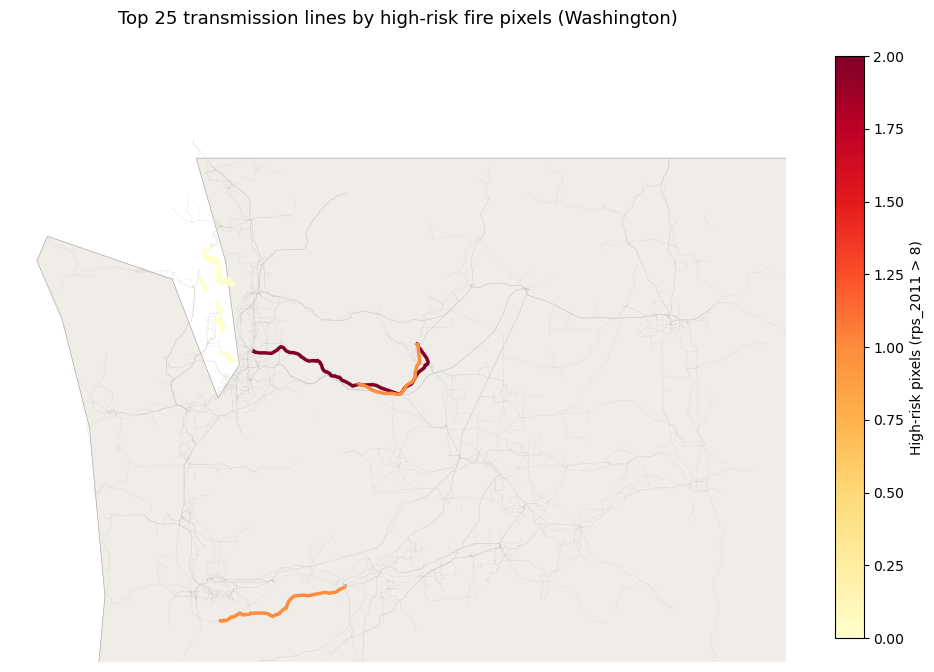

In [10]:
top25 = ranked.head(25)

ne_url = 'https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip'
world = gpd.read_file(ne_url)
conus = world[world['ISO_A3'] == 'USA']

fig, ax = plt.subplots(figsize=(10, 10))
conus.plot(ax=ax, color='#f0ede8', edgecolor='#aaa', linewidth=0.5)

# All western lines in light grey for context
lines.plot(ax=ax, color='#cccccc', linewidth=0.3, alpha=0.5, label='All transmission lines')

# Top 25 coloured by high-risk pixel count
top25.plot(
    ax=ax,
    column='high_risk_pixels',
    cmap='YlOrRd',
    linewidth=2.5,
    legend=True,
    legend_kwds={'label': 'High-risk pixels (rps_2011 > 8)', 'shrink': 0.6},
)

ax.set_xlim(-125, -116)
ax.set_ylim(45, 50)
ax.set_title('Top 25 transmission lines by high-risk fire pixels (Washington)', fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Bar chart: top 25 lines ranked by high-risk pixel count

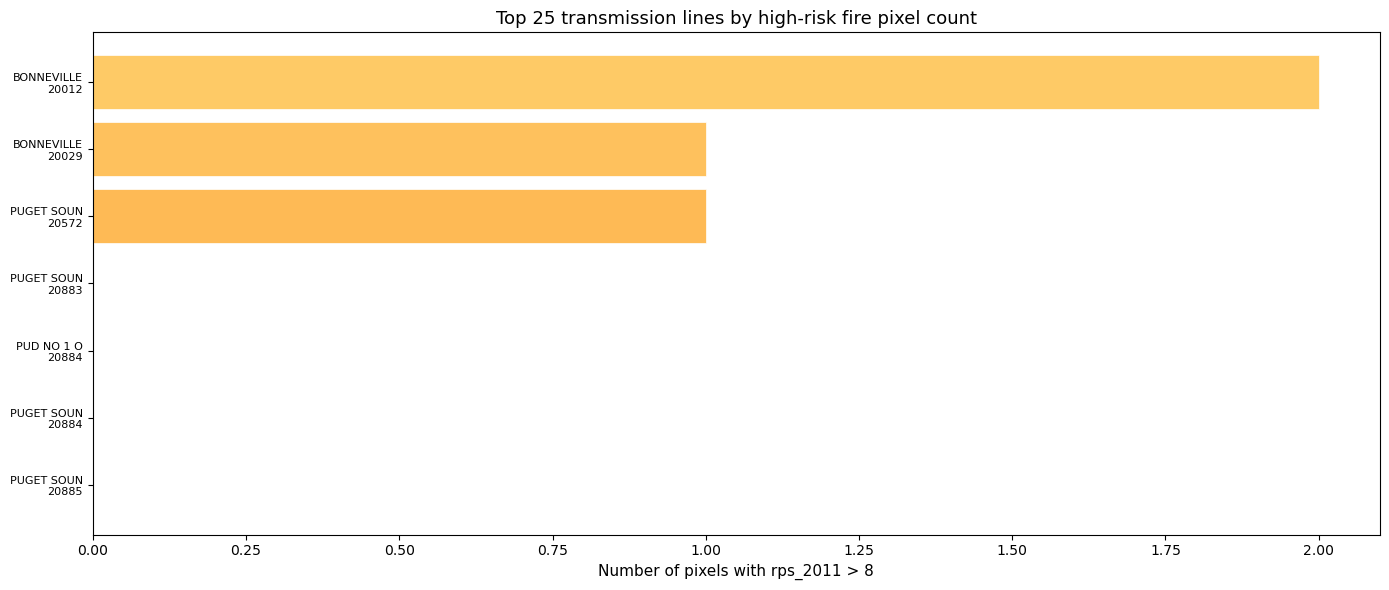

In [14]:
# Use a short label: owner + line ID (truncated)
top25 = top25.copy()
top25['label'] = (
    top25['OWNER'].fillna('Unknown').str[:10] + '\n' + top25['ID'].fillna('').astype(str).str[:5]
)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(
    top25['label'][::-1],
    top25['high_risk_pixels'][::-1],
    color=plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(top25)))[::-1],
    edgecolor='white',
    linewidth=0.5,
)
ax.set_xlabel('Number of pixels with rps_2011 > 8', fontsize=11)
ax.set_title('Top 25 transmission lines by high-risk fire pixel count', fontsize=13)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()